In [1]:
import asyncio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from clients import Clients
from mongo.schemas import PoolsSnapshotTrainRegressionV2, PoolsSnapshotTestRegressionV2

# Kết nối MongoDB
mongo_client = Clients.get_mongo_client()

2026-01-05 18:36:15,960 INFO [config] [__init__.py:70] [trace_id=0 span_id=0 resource.service.name= trace_sampled=False] - Loading configuration from: /home/pmv259/Documents/big-exercise/project1/lending-pool-score/model/app-config.yaml
2026-01-05 18:36:16,090 INFO [config] [__init__.py:96] [trace_id=0 span_id=0 resource.service.name= trace_sampled=False] - Configuration loaded successfully


In [3]:
async def load_data_v2():
    await mongo_client.initialize()
    
    print("Loading Train V2 data...")
    train_docs = await PoolsSnapshotTrainRegressionV2.find_many().to_list()
    df_train = pd.DataFrame([doc.model_dump() for doc in train_docs])
    
    print("Loading Test V2 data...")
    test_docs = await PoolsSnapshotTestRegressionV2.find_many().to_list()
    df_test = pd.DataFrame([doc.model_dump() for doc in test_docs])
    
    return df_train, df_test

In [4]:
# Load data 
df_train, df_test = await load_data_v2()

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

# Kiểm tra qua dữ liệu
df_train.head()

2026-01-05 18:36:28,840 INFO [clients.mongo_client] [mongo_client.py:27] [trace_id=0 span_id=0 resource.service.name= trace_sampled=False] - MongoDB client initialized.


Loading Train V2 data...
Loading Test V2 data...
Train shape: (141961, 16)
Test shape: (35494, 16)


,id,chain,project,symbol,pool_name,window_start_time,window_end_time,log_tvl,tvl_change_7d,tvl_volatility,max_drawdown,apy_mean,apy_std,chain_score,token_score,risk_score
0,db145a7e-fca6-4bd6-942c-c77ada2aae87,Ethereum,sky-lending,SUSDS,d8c4eff5-c8a9-46fc-a888-057c4c668e72,2025-02-21 23:01:33.435,2025-03-22 23:01:40.760,9.52,-0.0529,0.0808,-0.0755,6.72,0.69,1.0,5.0,1.71
1,a5a8ab02-3466-4556-b97c-0655f2cca7c4,Ethereum,sky-lending,SUSDS,d8c4eff5-c8a9-46fc-a888-057c4c668e72,2025-02-28 23:01:40.206,2025-03-29 23:02:27.757,9.47,-0.1065,0.0626,-0.1742,6.10,0.81,1.0,5.0,3.95
2,c07036e2-affc-477a-bbfb-50d0b0a50de9,Ethereum,sky-lending,SUSDS,d8c4eff5-c8a9-46fc-a888-057c4c668e72,2025-03-07 23:01:40.590,2025-04-05 23:02:40.594,9.48,0.0257,0.0671,-0.1743,5.63,1.01,1.0,5.0,2.46
3,b92f3a5a-5589-4cde-ab18-3a1b4fc8882c,Ethereum,sky-lending,SUSDS,d8c4eff5-c8a9-46fc-a888-057c4c668e72,2025-03-14 23:01:57.833,2025-04-12 23:01:19.449,9.39,-0.1822,0.0918,-0.3097,5.17,0.96,1.0,5.0,4.98
4,df294898-5c9e-4ca4-b9fc-9fce1222a79c,Ethereum,sky-lending,SUSDS,d8c4eff5-c8a9-46fc-a888-057c4c668e72,2025-03-21 23:02:49.685,2025-04-19 23:01:32.551,9.40,0.0218,0.1029,-0.2651,4.70,0.61,1.0,5.0,3.13


In [5]:
# ## 3. Feature Engineering (Define Features & Target)
# Danh sách Feature mới (8 features)
FEATURE_COLUMNS = [
    'log_tvl',          # Quy mô vốn (Logarit)
    'tvl_change_7d',    # Xu hướng dòng tiền
    'max_drawdown',     # Mức sụt giảm sâu nhất
    'tvl_volatility',   # Độ biến động TVL
    'apy_mean',         # Lợi nhuận trung bình
    'apy_std',          # Độ biến động lợi nhuận
    'chain_score',      # Điểm rủi ro Chain
    'token_score'       # Điểm uy tín Token (Quan trọng)
]

TARGET_COLUMN = 'risk_score'


# Tách X, y
X_train = df_train[FEATURE_COLUMNS]
y_train = df_train[TARGET_COLUMN]

X_test = df_test[FEATURE_COLUMNS]
y_test = df_test[TARGET_COLUMN]

print(f"Features sử dụng ({len(FEATURE_COLUMNS)}): {FEATURE_COLUMNS}")

Features sử dụng (8): ['log_tvl', 'tvl_change_7d', 'max_drawdown', 'tvl_volatility', 'apy_mean', 'apy_std', 'chain_score', 'token_score']


In [6]:
# ## 4. Baseline Model (Random Forest)

# Khởi tạo model với cấu hình cơ bản
rf_v2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train
print("Training Baseline Model...")
rf_v2.fit(X_train, y_train)

# Predict
y_pred = rf_v2.predict(X_test)

# Đánh giá
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("-" * 30)
print(f"BASELINE METRICS (V2 Data):")
print(f"MAE: {mae:.4f} (Sai số trung bình)")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")
print("-" * 30)

Training Baseline Model...
------------------------------
BASELINE METRICS (V2 Data):
MAE: 0.0385 (Sai số trung bình)
RMSE: 0.1070
R2 Score: 0.9969
------------------------------


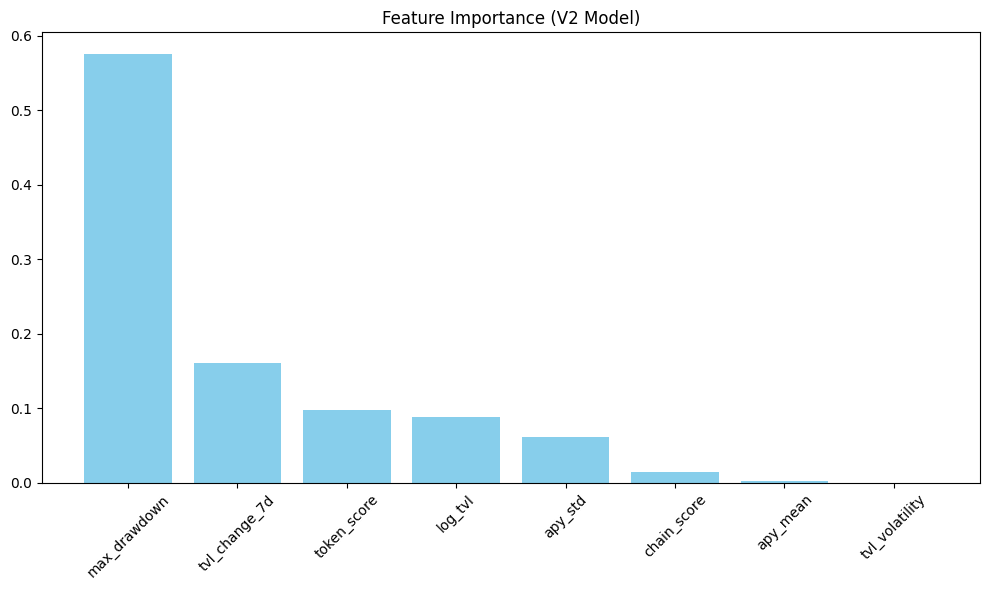

Độ quan trọng của các đặc trưng:
1. max_drawdown: 0.5759
2. tvl_change_7d: 0.1606
3. token_score: 0.0974
4. log_tvl: 0.0880
5. apy_std: 0.0612
6. chain_score: 0.0143
7. apy_mean: 0.0023
8. tvl_volatility: 0.0003


In [7]:
### 5. Phân tích Feature Importance

importances = rf_v2.feature_importances_
indices = np.argsort(importances)[::-1]

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.title("Feature Importance (V2 Model)")
plt.bar(range(X_train.shape[1]), importances[indices], align="center", color='skyblue')
plt.xticks(range(X_train.shape[1]), [FEATURE_COLUMNS[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

print("Độ quan trọng của các đặc trưng:")
for i in range(X_train.shape[1]):
    print(f"{i+1}. {FEATURE_COLUMNS[indices[i]]}: {importances[indices[i]]:.4f}")

In [8]:
# ## 6. Hyperparameter Tuning (Grid Search)
# Tinh chỉnh để tìm bộ tham số tốt nhất.

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

print("Đang chạy Grid Search (có thể mất vài phút)...")
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3, # Cross validation 3-fold để nhanh hơn
    n_jobs=-1,
    scoring='neg_mean_absolute_error',
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model_v2 = grid_search.best_estimator_
print(f"\nBest Params: {grid_search.best_params_}")

# Đánh giá lại với model tốt nhất
y_pred_opt = best_model_v2.predict(X_test)
mae_opt = mean_absolute_error(y_test, y_pred_opt)
r2_opt = r2_score(y_test, y_pred_opt)

print(f"Optimized MAE: {mae_opt:.4f}")
print(f"Optimized R2: {r2_opt:.4f}")

Đang chạy Grid Search (có thể mất vài phút)...
Fitting 3 folds for each of 54 candidates, totalling 162 fits


/home/pmv259/Documents/big-exercise/project1/lending-pool-score/model/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Params: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Optimized MAE: 0.0382
Optimized R2: 0.9969


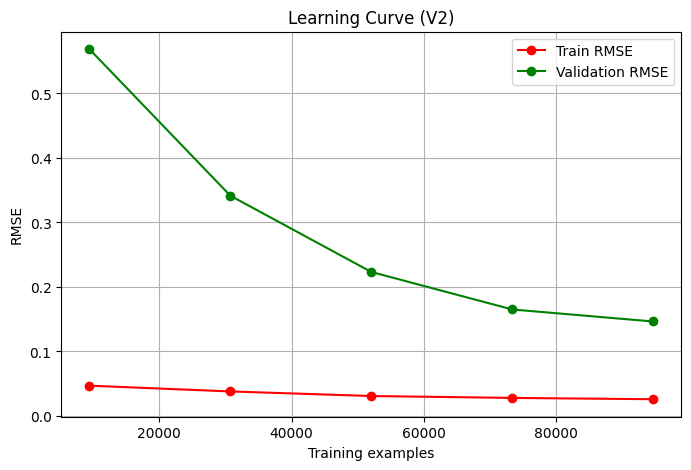

In [9]:
# ## 7. Learning Curve (Kiểm tra Overfitting)
# Xem khoảng cách giữa Train score và CV score có lớn không.

train_sizes, train_scores, test_scores = learning_curve(
    best_model_v2, X_train, y_train, 
    cv=3, scoring='neg_mean_squared_error',
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

train_rmse = np.sqrt(-np.mean(train_scores, axis=1))
test_rmse = np.sqrt(-np.mean(test_scores, axis=1))

plt.figure(figsize=(8, 5))
plt.title("Learning Curve (V2)")
plt.xlabel("Training examples")
plt.ylabel("RMSE")
plt.grid()
plt.plot(train_sizes, train_rmse, 'o-', color="r", label="Train RMSE")
plt.plot(train_sizes, test_rmse, 'o-', color="g", label="Validation RMSE")
plt.legend(loc="best")
plt.show()

In [10]:
# ## 8. Lưu Model và Test thử
# Lưu lại model để dùng cho API.

# Lưu model
model_filename = 'risk_score_model_v2.pkl'
joblib.dump(best_model_v2, model_filename)
print(f"Đã lưu model vào: {model_filename}")

# Test thử một vài case điển hình từ tập Test
print("\n--- Kiểm tra thực tế một số mẫu ---")
sample_indices = np.random.choice(len(X_test), 5, replace=False)
for i in sample_indices:
    sample_X = X_test.iloc[i]
    true_y = y_test.iloc[i]
    pred_y = best_model_v2.predict([sample_X])[0]
    
    print(f"Pool Index {i}:")
    print(f" - Input: TVL={10**sample_X['log_tvl']:.0f}, Drawdown={sample_X['max_drawdown']:.2%}, TokenScore={sample_X['token_score']}")
    print(f" - Thực tế: {true_y:.2f} | Dự đoán: {pred_y:.2f} | Sai lệch: {abs(true_y - pred_y):.2f}")
    print("-" * 20)

Đã lưu model vào: risk_score_model_v2.pkl

--- Kiểm tra thực tế một số mẫu ---
Pool Index 18085:
 - Input: TVL=117490, Drawdown=-0.08%, TokenScore=8.0
 - Thực tế: 4.07 | Dự đoán: 4.09 | Sai lệch: 0.02
--------------------
Pool Index 12113:
 - Input: TVL=5370318, Drawdown=-20.28%, TokenScore=8.0
 - Thực tế: 4.47 | Dự đoán: 4.46 | Sai lệch: 0.01
--------------------
Pool Index 9204:
 - Input: TVL=371535, Drawdown=-90.20%, TokenScore=8.0
 - Thực tế: 8.44 | Dự đoán: 8.41 | Sai lệch: 0.03
--------------------
Pool Index 20105:
 - Input: TVL=338844, Drawdown=-11.57%, TokenScore=8.0
 - Thực tế: 6.23 | Dự đoán: 6.39 | Sai lệch: 0.16
--------------------
Pool Index 5613:
 - Input: TVL=1862087, Drawdown=-18.90%, TokenScore=1.0
 - Thực tế: 3.10 | Dự đoán: 3.22 | Sai lệch: 0.12
--------------------


/home/pmv259/Documents/big-exercise/project1/lending-pool-score/model/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/home/pmv259/Documents/big-exercise/project1/lending-pool-score/model/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/home/pmv259/Documents/big-exercise/project1/lending-pool-score/model/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/home/pmv259/Documents/big-exercise/project1/lending-pool-score/model/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor